## GET DATASET

In [ ]:
from google.colab import files

uploaded = files.upload()  # This will open a file upload dialog


Saving FINAL_CLEANED_CORRECTED_SHUFFLED_DATASET_NO_DUPLICATE.jsonl to FINAL_CLEANED_CORRECTED_SHUFFLED_DATASET_NO_DUPLICATE.jsonl


## LIBraries

In [ ]:
# Import required libraries
from sklearn.preprocessing import LabelEncoder
import torch
from sklearn.model_selection import train_test_split
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score

In [ ]:
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments



## Distilbert

In [ ]:
import pandas as pd
from transformers import AdamW
df = pd.read_json("FINAL_CLEANED_CORRECTED_SHUFFLED_DATASET_NO_DUPLICATE.jsonl", lines=True)
df.head()
# Initialize a label encoder for polarity
label_encoder = LabelEncoder()
# Correct order: 0=negative, 1=neutral, 2=positive
label_encoder.fit(["negative", "neutral", "positive"])  # Order matters! # Fit on possible polarities

# Function to preprocess the data
def preprocess_data(df):
    texts = []
    aspects = []
    polarities = []

    for _, row in df.iterrows():
        text = row["text"]
        labels = row["labels"]  # Directly use the column value  # Convert string to list of dictionaries

        for label in labels:
            aspect = label["aspect"]
            polarity = label["polarity"]
            texts.append(text)
            aspects.append(aspect)
            polarities.append(polarity)

    # Encode polarities into numerical labels
    polarities = label_encoder.transform(polarities)
    print("Encoded polarities:", polarities[:10])  # Should output [0, 1, 2, ...] matching your classes
    return texts, aspects, polarities

# Preprocess the dataset
texts, aspects, polarities = preprocess_data(df)

# Split the dataset into train, validation, and test sets
train_texts, temp_texts, train_aspects, temp_aspects, train_polarities, temp_polarities = train_test_split(
    texts, aspects, polarities, test_size=0.3, random_state=42
)

val_texts, test_texts, val_aspects, test_aspects, val_polarities, test_polarities = train_test_split(
    temp_texts, temp_aspects, temp_polarities, test_size=0.5, random_state=42
)

print(f"Train size: {len(train_texts)}")
print(f"Validation size: {len(val_texts)}")
print(f"Test size: {len(test_texts)}")

# Tokenize the data
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')


def tokenize_data(texts, aspects):
    return tokenizer(texts, aspects, padding=True, truncation=True, return_tensors="pt")

train_inputs = tokenize_data(train_texts, train_aspects)
val_inputs = tokenize_data(val_texts, val_aspects)
test_inputs = tokenize_data(test_texts, test_aspects)

# Convert labels to PyTorch tensors
train_labels = torch.tensor(train_polarities)
val_labels = torch.tensor(val_polarities)
test_labels = torch.tensor(test_polarities)

# Create DataLoaders
train_dataset = TensorDataset(train_inputs["input_ids"], train_inputs["attention_mask"], train_labels)
val_dataset = TensorDataset(val_inputs["input_ids"], val_inputs["attention_mask"], val_labels)
test_dataset = TensorDataset(test_inputs["input_ids"], test_inputs["attention_mask"], test_labels)

from torch.utils.data import DataLoader

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,  # Adjust batch size as needed
    shuffle=True,
    num_workers=2,  # Use multiple workers for faster data loading
    pin_memory=True  # Speed up data transfer to GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    num_workers=2,
    pin_memory=True
)
# Debug DataLoader
for i, batch in enumerate(train_loader):
    input_ids, attention_mask, labels = batch
    print(f"Batch {i + 1}:")
    print(f"Input IDs shape: {input_ids.shape}")
    print(f"Attention mask shape: {attention_mask.shape}")
    print(f"Labels shape: {labels.shape}")
    break  # Only check the first batch
# Load the model
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)
# ✅ Add this after loading the model to correctly map labels
model.config.id2label = {0: "negative", 1: "neutral", 2: "positive"}
model.config.label2id = {"negative": 0, "neutral": 1, "positive": 2}
# Set up optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# Define device (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


model.to(device)  # Move model to GPU/CPU






Encoded polarities: [2 0 2 2 1 1 0 0 0 1]
Train size: 21569
Validation size: 4622
Test size: 4622
Batch 1:
Input IDs shape: torch.Size([32, 128])
Attention mask shape: torch.Size([32, 128])
Labels shape: torch.Size([32])


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda
Using device: cuda


/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Training Loop

In [ ]:
# Training loop
for epoch in range(3):  # Adjust epochs as needed
    model.train()
    total_loss = 0

    for i, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch + 1}")):
        input_ids, attention_mask, labels = batch

        # Move data to the same device as the model
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        #print(f"Step {i + 1}: Forward pass complete, Loss = {loss.item()}")

        # Backward pass
        loss.backward()
        #print(f"Step {i + 1}: Backward pass complete")

        # Update weights
        optimizer.step()
       # print(f"Step {i + 1}: Optimizer step complete")

        # Zero gradients
        optimizer.zero_grad()
        #print(f"Step {i + 1}: Gradients zeroed")

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {total_loss / len(train_loader)}")

Epoch 1: 100%|██████████| 675/675 [03:27<00:00,  3.25it/s]


Epoch 1, Loss: 0.5176478359986234


Epoch 2: 100%|██████████| 675/675 [03:33<00:00,  3.17it/s]


Epoch 2, Loss: 0.29220042765968374


Epoch 3: 100%|██████████| 675/675 [03:32<00:00,  3.17it/s]

Epoch 3, Loss: 0.17783019493161528


## Evaluation Loop

In [ ]:
# Evaluation code (add your validation/test code here)
def evaluate(model, val_loader):
    model.eval()
    true_labels = []
    preds = []
    with torch.no_grad():
        for batch in val_loader:
            # Access tensors by index (input_ids, attention_mask, labels)
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            batch_preds = torch.argmax(logits, dim=1)

            true_labels.extend(labels.cpu().numpy())
            preds.extend(batch_preds.cpu().numpy())

    return accuracy_score(true_labels, preds)

val_accuracy = evaluate(model, val_loader)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
# Evaluate on test set
test_accuracy = evaluate(model, test_loader)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Save the model
model.save_pretrained("absa_distilbert_model")
tokenizer.save_pretrained("absa_distilbert_tokenizer")

Validation Accuracy: 85.55%
Test Accuracy: 85.98%


('absa_distilbert_tokenizer/tokenizer_config.json',
 'absa_distilbert_tokenizer/special_tokens_map.json',
 'absa_distilbert_tokenizer/vocab.txt',
 'absa_distilbert_tokenizer/added_tokens.json',
 'absa_distilbert_tokenizer/tokenizer.json')

## Test

In [ ]:
text = "The food at the resturant was amazing but service was terrible."
aspect = "food"  # Specify the aspect
# Define the correct mapping manually
id2label = {0: "negative", 1: "neutral", 2: "positive"}
inputs = tokenizer(text, aspect, return_tensors="pt", truncation=True).to(device)  # Include aspect!

with torch.no_grad():
    logits = model(**inputs).logits  # Get model predictions

predicted_class = torch.argmax(logits, dim=1).item()  # Get the predicted label index
predicted_label = model.config.id2label[predicted_class]  # Convert index to class

print(f"Predicted Sentiment for '{aspect}': {predicted_label}")


Predicted Sentiment for 'food': positive


## Mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Model Saved

In [ ]:
from transformers import RobertaForSequenceClassification, RobertaTokenizer

# Define save paths (adjust as needed)
SAVE_PATH = "/content/drive/MyDrive/saved_model_distilbert/"  # Google Drive path
# SAVE_PATH = "./my_model/"  # Local Colab path

# Save model and tokenizer
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"Model and tokenizer saved to {SAVE_PATH}")

NameError: name 'model' is not defined


# LIME XAI TECHNIQUE

Install Required Libraries

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4447968af6f597e0c0929765ee8f4f7a5dde1b01d89e3d94bb6191fb29c4f67c
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Load saved model and tokenizer
model_path = "/content/drive/MyDrive/saved_model_distilbert/"  # Update path
model =  AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()  # Set evaluation mode

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
def predict_sentiment(texts, aspects):
    predictions = []
    for text, aspect in zip(texts, aspects):
        # Tokenize EXACTLY as done during training (text + aspect)
        inputs = tokenizer(
            text,
            aspect,  # <-- Critical: Match training's text+aspect format
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            probabilities = torch.nn.functional.softmax(outputs.logits, dim=1).cpu().numpy()
        predictions.append(probabilities[0])
    return np.array(predictions)

In [ ]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(
    class_names=["negative", "neutral", "positive"]
)

In [ ]:
import numpy as np
text = "The food at the restaurant was amazing, but the service was terrible."
target_aspect = "food"  # Aspect to analyze

def lime_predict(texts):
    # Fix aspect for all perturbed texts
    aspects = [target_aspect] * len(texts)
    return predict_sentiment(texts, aspects)

# Generate explanation for the target aspect
explainer = LimeTextExplainer(class_names=["negative", "neutral", "positive"])
exp = explainer.explain_instance(
    text,
    lime_predict,
    num_features=5,
    num_samples=1000
)

In [ ]:
# Add this to debug your tokenization
sample_text = "Sample text"
sample_aspect = "sample aspect"
tokenized = tokenizer(sample_text, sample_aspect, padding=True, truncation=True)
print("Tokenized input:", tokenizer.decode(tokenized["input_ids"]))
# Output should look like: "<s>Sample text [SEP] sample aspect</s>"

Tokenized input: [CLS] sample text [SEP] sample aspect [SEP]


In [ ]:
def explain_instance_with_class_columns(text, aspect):
    def lime_predict(texts):
        aspects = [aspect] * len(texts)
        return predict_sentiment(texts, aspects)

    exp = explainer.explain_instance(
        text,
        lime_predict,
        num_features=5,
        num_samples=1000,
        labels=[0, 1, 2]
    )

    print(f"\nExplanation for Aspect: {aspect}")
    for class_idx in [0, 1, 2]:
        print(f"\nClass: {model.config.id2label[class_idx]}")
        features = exp.as_list(class_idx)
        for feature, weight in features:
            print(f"{feature}: {weight}")

    exp.show_in_notebook(text=text)

# Example usage
text = "The food at the restaurant was amazing, but the service was terrible."
explain_instance_with_class_columns(text, aspect="food")
explain_instance_with_class_columns(text, aspect="service")


Explanation for Aspect: food

Class: negative
service: -0.24380477290581665
food: -0.2303265473994819
amazing: -0.2239068196263135
terrible: 0.08769110932795417
the: -0.06850935917857491

Class: neutral
amazing: -0.43444607556257353
service: 0.1545369595070024
food: -0.10018889541473437
terrible: -0.047630002036370835
The: -0.04442455703669771

Class: positive
amazing: 0.6527185143788583
food: 0.3279038112019849
service: 0.08669514976624557
the: 0.06868703165152336
The: 0.05100656193030912



Explanation for Aspect: service

Class: negative
terrible: 0.3293653741815787
but: 0.2722135429101
service: 0.05446650039233156
was: 0.03435729933035574
amazing: -0.02856956666496119

Class: neutral
terrible: -0.10325948812509783
but: -0.07520890449880473
amazing: -0.07007254902601358
at: -0.01822104566307696
service: -0.01753470372227203

Class: positive
terrible: -0.22231942711844968
but: -0.1931298289908131
amazing: 0.09854596823732263
food: -0.04002845677390034
service: -0.03198777979839762


In [ ]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.5 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.46.0
    Uninstalling shap-0.46.0:
      Successfully uninstalled shap-0.46.0


In [ ]:
import shap
import torch
from transformers import AutoTokenizer

def predict_aspect(texts, aspect="food"):
    """
    Returns model probabilities for texts combined with a fixed aspect.
    """
    # Combine text and aspect using the same separator as in training
    combined_texts = [f"{text} [SEP] {aspect}" for text in texts]  # Match training separator

    # Tokenize
    inputs = tokenizer(
        combined_texts,
        padding=True,
        truncation=True,
        max_length=128,  # Match training max_length
        return_tensors="pt"
    ).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits to probabilities
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=1).cpu().numpy()
    return probabilities

In [ ]:
# Target text and aspect
text_to_explain = "The food at the restaurant was amazing, but the service was terrible."
aspect = "food"  # Aspect to analyze

# Wrap prediction function to fix the aspect
def predict(texts):
    return predict_aspect(texts, aspect=aspect)

# Initialize SHAP explainer
explainer = shap.Explainer(
    predict,
    masker= shap.maskers.Text(tokenizer),  # Perturb words in the text (not the aspect)
    output_names=["negative", "neutral", "positive"]
)

# Compute SHAP values
shap_values = explainer([text_to_explain])


  0%|          | 0/240 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:23, 23.84s/it]               


In [ ]:
shap.plots.text(shap_values)

In [ ]:
import numpy as np
import shap

# Suppose 'shap_values' is your original Explanation object
# e.g., from shap_values = explainer(["some text"]).

# 1) Find the absolute maximum
abs_max = np.max(np.abs(shap_values.values))

# 2) Scale the values so that the largest absolute value becomes ±1
scaled_vals = shap_values.values / abs_max

# 3) Create a new Explanation object with these scaled values
scaled_shap = shap.Explanation(
    values=scaled_vals,
    base_values=shap_values.base_values,  # Usually we keep base_values unscaled for interpretability
    data=shap_values.data,
    output_names=shap_values.output_names
)


In [ ]:
force_plot = shap.force_plot(
    base_value=scaled_shap.base_values[0, class_idx],
    shap_values=scaled_shap.values[0, :, class_idx],
    features=scaled_shap.data[0]
)
shap.save_html("force_plot.html", force_plot)


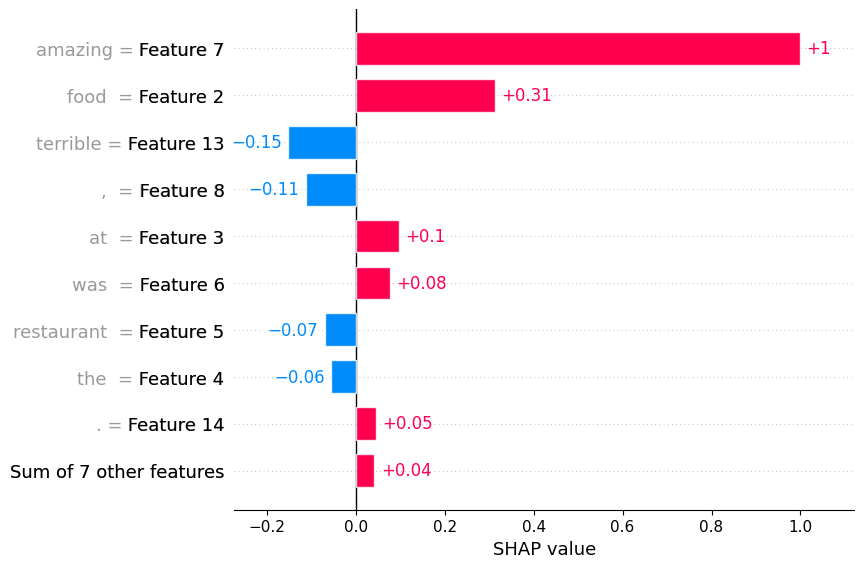

In [ ]:
shap.plots.bar(scaled_shap[0, :, 2])


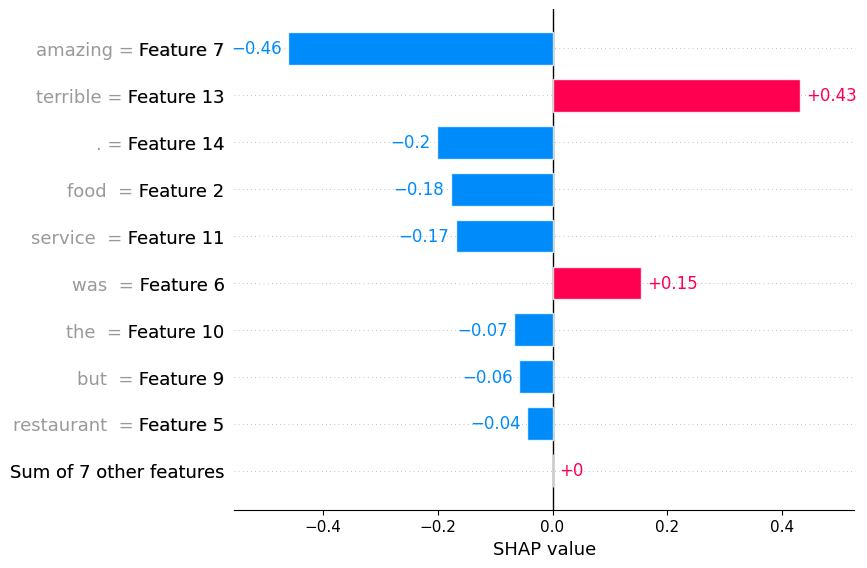

In [ ]:
shap.plots.bar(scaled_shap[0, :, 0])

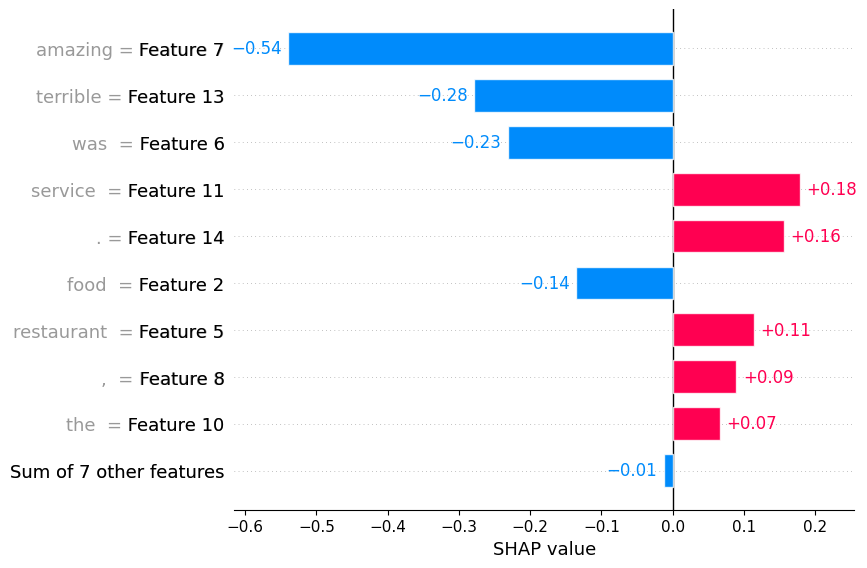

In [ ]:
shap.plots.bar(scaled_shap[0, :, 1])

## Grad cam

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Load saved model and tokenizer
model_path = "/content/drive/MyDrive/saved_model_distilbert/"  # Update path
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()  # Set evaluation model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Grad-CAM Relevance Scores for Aspect 'food' in Input Text:
[CLS]: 0.5528
the: 1.0000
food: 0.7590
at: 0.8997
the: 0.9712
restaurant: 0.0000
was: 0.9959
amazing: 0.7679
,: 0.6379
but: 0.0000
the: 0.2323
service: 0.2051
was: 0.1349
terrible: 0.1462
.: 0.7068
[SEP]: 0.8589
food: 0.3837
[SEP]: 0.8589

Predicted Polarity for Aspect 'food': positive


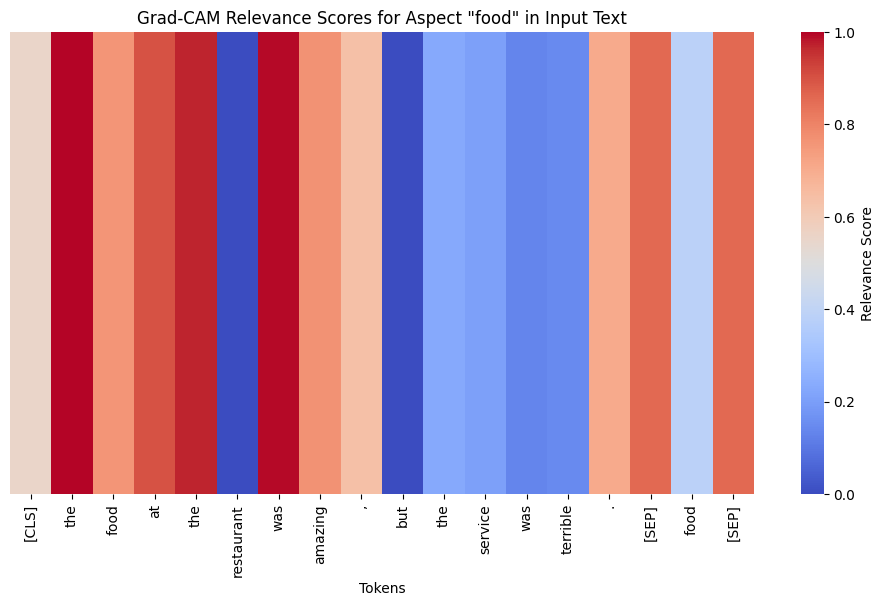

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns


class GradCam:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        self.target_layer.register_forward_hook(self.save_activations)
        self.target_layer.register_full_backward_hook(self.save_gradients)


    def save_activations(self, module, input, output):
        # Handle the tuple case for XLNet
        if isinstance(output, tuple):
            self.activations = output[0]
        else:
            self.activations = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def compute_gradcam(self, input_text, aspect, tokenizer):
        combined_input = f"{input_text} [SEP] {aspect}"
        inputs = tokenizer(combined_input, return_tensors='pt')

        # Move inputs to the same device as the model
        device = next(self.model.parameters()).device
        inputs = {key: val.to(device) for key, val in inputs.items()}

        self.model.eval()
        outputs = self.model(**inputs)

        target_class = torch.argmax(outputs.logits, dim=1).item()
        target_score = outputs.logits[0, target_class]

        self.model.zero_grad()
        target_score.backward()

        gradients = self.gradients.mean(dim=1).squeeze()
        activations = self.activations.squeeze()

        weights = gradients
        cam = torch.zeros(activations.size(0), device=device)  # Ensure same device

        for i in range(activations.size(0)):
            cam[i] = (weights * activations[i]).sum()

        cam = torch.relu(cam)
        cam = cam / cam.max()

        return cam.cpu(), inputs['input_ids'][0].cpu(), target_class  # Move to CPU for visualization



# Example
input_text = "The food at the restaurant was amazing, but the service was terrible."
aspect = "food"


# ✅ Correct target layer for DistilBERT (use .ffn.lin2)
target_layer = model.distilbert.transformer.layer[-1].ffn.lin2

# Initialize Grad-CAM
gradcam = GradCam(model, target_layer)

# Compute Grad-CAM scores for the aspect
cam_scores, input_ids, target_class = gradcam.compute_gradcam(input_text, aspect, tokenizer)

# Convert token IDs to tokens
tokens = tokenizer.convert_ids_to_tokens(input_ids)

# Combine tokens with their corresponding Grad-CAM scores
highlighted_text = [(token, score.item()) for token, score in zip(tokens, cam_scores)]

# Print the tokens with their relevance scores
print(f"Grad-CAM Relevance Scores for Aspect '{aspect}' in Input Text:")
for token, score in highlighted_text:
    print(f"{token}: {score:.4f}")

# Define a mapping from class index to sentiment polarity
polarity_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
predicted_polarity = polarity_mapping.get(target_class, 'unknown')

# Print the predicted polarity
print(f"\nPredicted Polarity for Aspect '{aspect}': {predicted_polarity}")

# Visualize the results in a heatmap without annotations
plt.figure(figsize=(12, 6))
ax = sns.heatmap([cam_scores.detach().numpy()], cmap='coolwarm', cbar_kws={'label': 'Relevance Score'})
ax.set_title(f'Grad-CAM Relevance Scores for Aspect "{aspect}" in Input Text')
ax.set_xlabel('Tokens')
ax.set_xticklabels(tokens, rotation=90)  # Rotate words to be vertical
plt.yticks([], [])  # Hide y-axis labels

# Show the plot
plt.show()

## Distilbert:

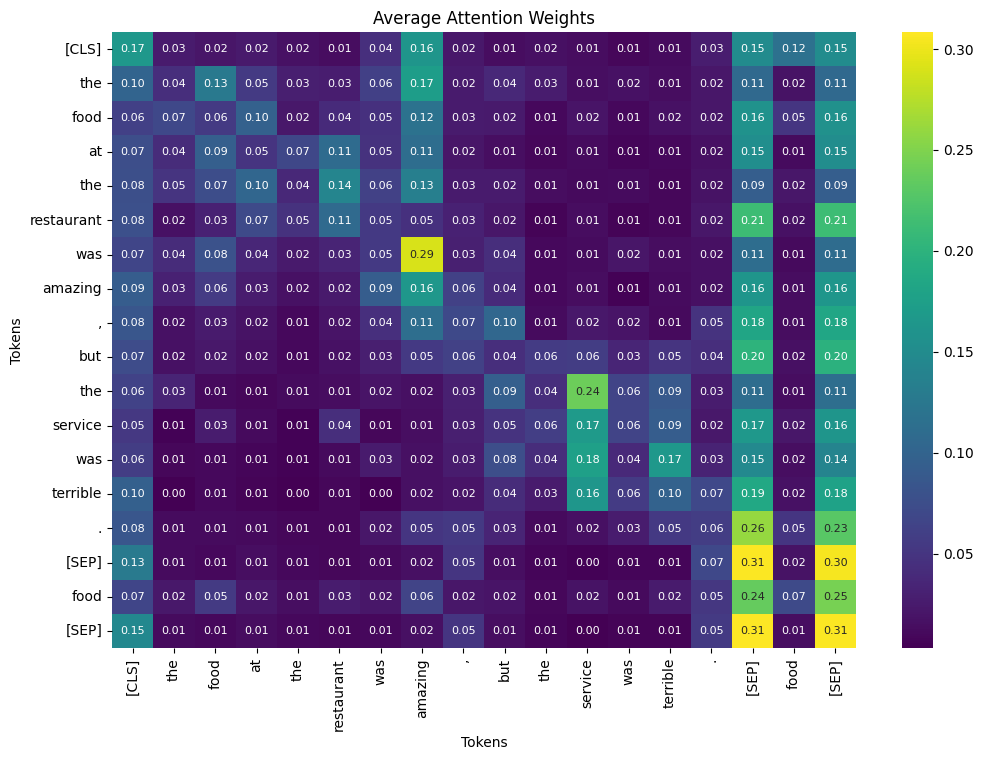

In [ ]:
import seaborn as sns
# Example review and aspect
input_text = "The food at the restaurant was amazing, but the service was terrible."
aspect = "food"

# Combine text and aspect using the [SEP] token
combined_text = f"{input_text} [SEP] {aspect}"

# Tokenize the input
inputs = tokenizer(combined_text, return_tensors="pt", truncation=True, padding=True)
# Get model outputs with attention weights
outputs = model(**inputs, output_attentions=True)
attentions = outputs.attentions  # Tuple of attention matrices

# Average over all layers and heads:
attentions_np = [att.detach().cpu().numpy() for att in attentions]  # List of arrays, each of shape: [batch, num_heads, seq_len, seq_len]
# Concatenate along the head dimension
concatenated = np.concatenate(attentions_np, axis=1)  # shape: [batch, total_heads, seq_len, seq_len]
avg_attention = np.mean(concatenated, axis=1)[0]       # shape: [seq_len, seq_len]

# Get tokens for labeling the heatmap
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Plot the averaged attention as a heatmap with annotated values
plt.figure(figsize=(12, 8))
ax = sns.heatmap(avg_attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis", annot=True, fmt=".2f", annot_kws={"size":8})
ax.set_title("Average Attention Weights")
ax.set_xlabel("Tokens")
ax.set_ylabel("Tokens")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()